In [1]:
# 경고 메시지 무시
import warnings
warnings.filterwarnings(action='ignore') 

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import csv
import folium
import datetime
import seaborn as sns
import scipy as sp
import statsmodels.formula.api as smf
import networkx as nx
import missingno as msno
import os
import sys
import urllib.request
import time
import json
import plotly.express as px
import re
import sklearn.metrics as metrics

from sklearn.decomposition import PCA
from sklearn import datasets
from folium.plugins import HeatMap 
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from dateutil.relativedelta import relativedelta
from sklearn.cluster import KMeans    
from yellowbrick.cluster import KElbowVisualizer
from scipy.cluster.hierarchy import dendrogram, linkage
from mpl_toolkits.mplot3d import Axes3D
from operator import itemgetter
from PIL import Image
from collections import Counter
from wordcloud import WordCloud
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score, ConfusionMatrixDisplay, confusion_matrix, silhouette_score, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# plt.rc('font', family='malgun gothic')
# plt.rcParams['axes.unicode_minus']=False  # '- 표시
plt.rc('font',family='D2CodingLigature Nerd Font')

* Happiness score   행복 점수
* upperwhisker   신뢰구간 상한값
* lowerwhisker   신뢰구간 하한값
* GDP per capita   1인당 GDP
* Social support   사회적 지원
* Healthy life expectancy   기대수명(건강 수명)
* Freedom to make life choices   삶의 선택의 자유
* Generosity   관대함(기부·나눔 수준)
* Dystopia   디스토피아 기준값(최저 행복 기준)

In [10]:
df2020=pd.read_csv('../../data/2020.csv',index_col=0)
df2021=pd.read_csv('../../data/2021.csv',index_col=0)
df2020.head()

,Country name,Happiness score,upperwhisker,lowerwhisker,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Dystopia
Rank,,,,,,,,,,
1,Finland,7.8087,7.869766,7.747634,10.639267,0.954330,71.900825,0.949172,-0.059482,2.762835
2,Denmark,7.6456,7.711245,7.579955,10.774001,0.955991,72.402504,0.951444,0.066202,2.432741
3,Switzerland,7.5599,7.628528,7.491272,10.979933,0.942847,74.102448,0.921337,0.105911,2.350267
4,Iceland,7.5045,7.621347,7.387653,10.772559,0.974670,73.000000,0.948892,0.246944,2.460688
5,Norway,7.4880,7.556281,7.419719,11.087804,0.952487,73.200783,0.955750,0.134533,2.168266


In [11]:
df2021.head()

,Country name,Happiness score,upperwhisker,lowerwhisker,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Dystopia
Rank,,,,,,,,,,
1,Finland,7.842,7.904,7.780,10.775,0.954,72.0,0.949,-0.098,3.253
2,Denmark,7.620,7.687,7.552,10.933,0.954,72.7,0.946,0.030,2.868
3,Switzerland,7.571,7.643,7.500,11.117,0.942,74.4,0.919,0.025,2.839
4,Iceland,7.554,7.670,7.438,10.878,0.983,73.0,0.955,0.160,2.967
5,Netherlands,7.464,7.518,7.410,10.932,0.942,72.4,0.913,0.175,2.798


## 데이터 가공

In [12]:
## 불필요한 컬럼 삭제

df2020.drop(['upperwhisker','lowerwhisker','Dystopia'],axis=1,inplace=True)
df2021.drop(['upperwhisker','lowerwhisker','Dystopia'],axis=1,inplace=True)

In [13]:
df2020.head()

,Country name,Happiness score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity
Rank,,,,,,,
1,Finland,7.8087,10.639267,0.954330,71.900825,0.949172,-0.059482
2,Denmark,7.6456,10.774001,0.955991,72.402504,0.951444,0.066202
3,Switzerland,7.5599,10.979933,0.942847,74.102448,0.921337,0.105911
4,Iceland,7.5045,10.772559,0.974670,73.000000,0.948892,0.246944
5,Norway,7.4880,11.087804,0.952487,73.200783,0.955750,0.134533


In [14]:
df2021.head()

,Country name,Happiness score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity
Rank,,,,,,,
1,Finland,7.842,10.775,0.954,72.0,0.949,-0.098
2,Denmark,7.620,10.933,0.954,72.7,0.946,0.030
3,Switzerland,7.571,11.117,0.942,74.4,0.919,0.025
4,Iceland,7.554,10.878,0.983,73.0,0.955,0.160
5,Netherlands,7.464,10.932,0.942,72.4,0.913,0.175


In [15]:
## 모든 컬럼들의 빈공백을 마침표(.)로 변경
df2020.columns = df2020.columns.str.replace(' ','_')
df2021.columns = df2021.columns.str.replace(' ','_')
df2020.head()

,Country_name,Happiness_score,GDP_per_capita,Social_support,Healthy_life_expectancy,Freedom_to_make_life_choices,Generosity
Rank,,,,,,,
1,Finland,7.8087,10.639267,0.954330,71.900825,0.949172,-0.059482
2,Denmark,7.6456,10.774001,0.955991,72.402504,0.951444,0.066202
3,Switzerland,7.5599,10.979933,0.942847,74.102448,0.921337,0.105911
4,Iceland,7.5045,10.772559,0.974670,73.000000,0.948892,0.246944
5,Norway,7.4880,11.087804,0.952487,73.200783,0.955750,0.134533


In [16]:
df2021.head()

,Country_name,Happiness_score,GDP_per_capita,Social_support,Healthy_life_expectancy,Freedom_to_make_life_choices,Generosity
Rank,,,,,,,
1,Finland,7.842,10.775,0.954,72.0,0.949,-0.098
2,Denmark,7.620,10.933,0.954,72.7,0.946,0.030
3,Switzerland,7.571,11.117,0.942,74.4,0.919,0.025
4,Iceland,7.554,10.878,0.983,73.0,0.955,0.160
5,Netherlands,7.464,10.932,0.942,72.4,0.913,0.175


## 데이터 시각화

In [18]:
# 행복 지수에 영향을 주는 요인 파악
# 행복 점수와 각 항목의 상관 관계

# 한 나라의 행복지수(Score)와 GDP, Freedom 사이의 상관관계

df1 = df2020.copy()
df1.drop(['Social_support','Healthy_life_expectancy','Generosity'],axis=1,inplace=True)
df1

,Country_name,Happiness_score,GDP_per_capita,Freedom_to_make_life_choices
Rank,,,,
1,Finland,7.8087,10.639267,0.949172
2,Denmark,7.6456,10.774001,0.951444
3,Switzerland,7.5599,10.979933,0.921337
4,Iceland,7.5045,10.772559,0.948892
5,Norway,7.4880,11.087804,0.955750
...,...,...,...,...
149,Central African Republic,3.4759,6.625160,0.640881
150,Rwanda,3.3123,7.600104,0.900589
151,Zimbabwe,3.2992,7.865712,0.711458


In [19]:
# 상관계수
corr=df1.corr(numeric_only=True)
corr

,Happiness_score,GDP_per_capita,Freedom_to_make_life_choices
Happiness_score,1.000000,0.775374,0.590597
GDP_per_capita,0.775374,1.000000,0.419019
Freedom_to_make_life_choices,0.590597,0.419019,1.000000


<Axes: >

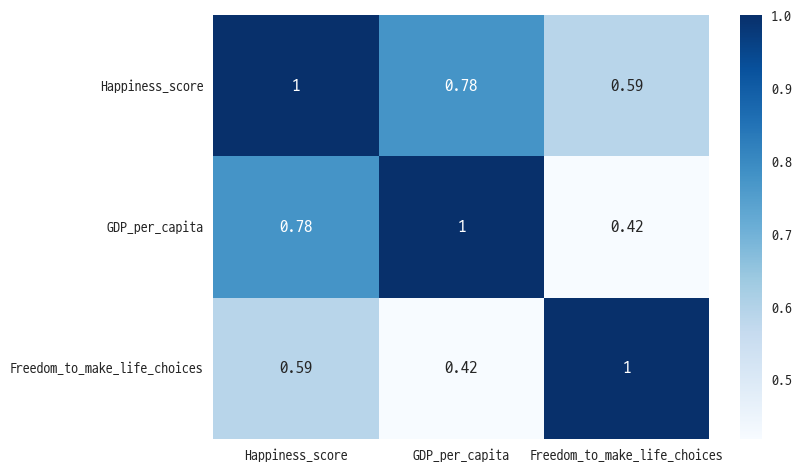

In [20]:
## 히트맵
sns.heatmap(corr,annot=True,cmap='Blues')

In [23]:
df2 = df2021.copy()
df2.drop(['Social_support','Healthy_life_expectancy','Generosity'],axis=1,inplace=True)
corr2=df2.corr(numeric_only=True)
corr2

,Happiness_score,GDP_per_capita,Freedom_to_make_life_choices
Happiness_score,1.000000,0.789760,0.607753
GDP_per_capita,0.789760,1.000000,0.432323
Freedom_to_make_life_choices,0.607753,0.432323,1.000000


<Axes: >

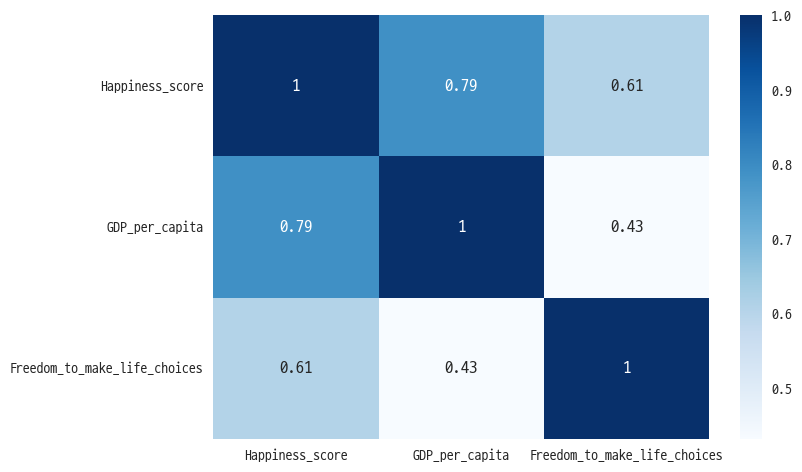

In [ ]:
## 히트맵
sns.heatmap(corr2,annot=True,cmap='Blues')

In [25]:
df3 = df2020[['Generosity','Social_support','Happiness_score']].copy()
corr3 = df3.corr()
corr3

,Generosity,Social_support,Happiness_score
Generosity,1.000000,-0.056780,0.069043
Social_support,-0.056780,1.000000,0.765001
Happiness_score,0.069043,0.765001,1.000000


<Axes: >

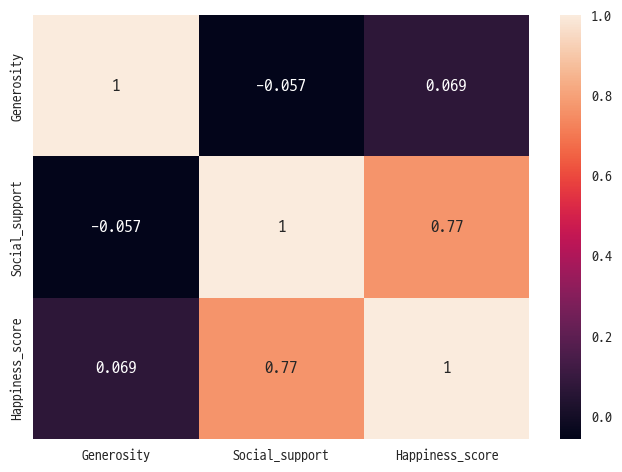

In [28]:
sns.heatmap(corr3, annot=True)